# Human Decision Making Under Uncertainty - Romain Gazon (8230028)

The [choices13k](https://github.com/jcpeterson/choices13k) contains human decision rates on 13006 risky
choice problems. The purpose of the dataset is to study how people make decisions under uncertaintly. 

Participants in the study were presented with two decision scenarios ("gambles") and were asked to select 
the most appealing of them. Both gambles were represented to participants as a list of rewards and
their associated probabilities. Based on that, the participants selected either Gamble A or Gamble B.

In this assignment, we develop machine learning models to predict the frequency with which the participants
selected Gamble B (`bRate`) using the **choices13k** dataset available on the project's [GitHub repository](https://github.com/jcpeterson/choices13k).
In addition to evaluating predictive performance, we investigate which lottery characteristics and 
engineered behavioural features are most influential in explaining human decision-making under uncertainty.

With thanks to the researchers who made this dataset:

- Peterson, J. C., Bourgin, D. D., Agrawal, M., Reichman, D., & Griffiths, T. L. (2021). *Using large-scale experiments and machine learning to discover theories of human decision-making*. **Science**, 372(6547), 1209–1214.

- Bourgin, D. D., Peterson, J. C., Reichman, D., Russell, S. J., & Griffiths, T. L. (2019). *Cognitive model priors for predicting human decisions*. In *Proceedings of the 36th International Conference on Machine Learning (PMLR)*, 97, 5133–5141.

## Imports

Following standard practice, and for the convenience of the grader, all imports are placed at the beginning in the cell below.

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from scipy.stats import sem

import shap

from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_validate,
)

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

from statsmodels.stats.outliers_influence import variance_inflation_factor

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Construction

In [3]:
c13k = pd.read_csv('c13k_selections.csv')
c13k_problems = pd.read_json("c13k_problems.json", orient='index')
c13k = c13k.join(c13k_problems, how="left")
c13k.head(3)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"


## Feature Engineering

Before applying machine learning models to predict `bRate`, additional features will be derived from the
existing variables. To prevent data leakage, all engineered features are deterministic and do not incorporate
any information from the target variable.

Feature engineering is particularly important in this context because human decision-making under risk and
uncertainty is not fully captured by the raw attributes of the lotteries. Human choices often deviate from
strict rationality while remaining systematically predictable. Therefore, the engineered features aim to
capture aspects of how individuals *perceive* and evaluate risky alternatives rather than solely how those
alternatives are objectively defined.

Some of the derived variables are motivated by established theories of decision-making under risk and 
uncertainty, specifically `Expected Utility Theory` and `Cumulative Prospect Theory`. Others are designed to
quantify salient characteristics of the lotteries that may influence human preferences, including outcome 
asymmetry and potential gains.

*It has to be noted that a key modeling assumption is made when dealing with ambiguous gambles (`Amb = 1`) where
the probabilities associated with the outcomes of Gamble B are not known to the decision maker. In these cases,
whenever probabilities are required for feature construction, all possible outcomes are assumed to be equally 
likely.*

### Cumulative Prospect Theory (CPT)

[Cumulative Prospect Theory (CPT)](https://en.wikipedia.org/wiki/Cumulative_prospect_theory) is a descriptive
model of decision-making under risk and uncertainty proposed by Amos Tversky and Daniel Kahneman in 1992 
(Tversky & Kahneman, 1992). CPT aims to describe how individuals actually evaluate risky prospects. The 
framework has had a substantial impact on behavioral economics and decision science, and Kahneman was awarded
the 2002 Nobel Memorial Prize in Economic Sciences for his contributions
to this field.

According to Wikipedia:

> The main observation of CPT (and its predecessor prospect theory) is that people tend to think of possible
>  outcomes usually relative to a certain reference point (often the status quo) rather than to the final
> status, a phenomenon which is called framing effect. Moreover, they have different risk attitudes towards
>  gains (i.e. outcomes above the reference point) and losses (i.e. outcomes below the reference point) and
>  care generally more about potential losses than potential gains (loss aversion). Finally, people tend to
>  overweight extreme events, but underweight "average" events. The last point is in contrast to Prospect
>  Theory which assumes that people overweight unlikely events, independently of their relative outcomes.
> 
> CPT incorporates these observations in a modification of expected utility theory by replacing final wealth with
> payoffs relative to the reference point, replacing the utility function with a value function that depends on
> relative payoff, and replacing cumulative probabilities with weighted cumulative probabilities.

The implementation used in this project follows the methodology described in the [Program for Calculating the
Cumulative Prospect Theory Value of Prospects with at Most Four Outcomes](https://psych.fullerton.edu/mbirnbaum/calculators/cpt_calculator.htm)
by Veronika Köbberling. The original procedure was generalized to accommodate lotteries containing more than four
outcomes, allowing it to be applied consistently across the entire dataset.

In [4]:
def weighting_function(p, gain=True, gamma=0.61, delta=0.69):
    p = np.clip(p, 1e-10, 1)
    if gain:
        return (p ** gamma) / (
            (p ** gamma + (1 - p) ** gamma) ** (1 / gamma)
        )
    else:
        return (p ** delta) / (
            (p ** delta + (1 - p) ** delta) ** (1 / delta)
        )

def value_function(x, alpha=0.88, beta=0.88, lambda_=2.25):
    if x > 0:
        return x ** alpha
    elif x == 0:
        return 0
    else:
        return -lambda_ * ((-x) ** beta)

def cpt_value(outcomes):
    outcomes = sorted(outcomes, key=lambda t: t[1])
    gains  = [(p, x) for p, x in outcomes if x >= 0]
    losses = [(p, x) for p, x in outcomes if x < 0]
    total = 0

    #gains: highest to lowest
    cumulative = 0
    for p, x in reversed(gains):
        new_cumulative = cumulative + p
        pi = (
            weighting_function(new_cumulative, gain=True)
            - weighting_function(cumulative, gain=True)
        )
        total += pi * value_function(x)
        cumulative = new_cumulative

    #losses: lowest to highest
    cumulative = 0
    for p, x in losses:
        new_cumulative = cumulative + p
        pi = (
            weighting_function(new_cumulative, gain=False)
            - weighting_function(cumulative, gain=False)
        )
        total += pi * value_function(x)
        cumulative = new_cumulative

    return total

def get_outcomes(row):
    outcomes_a = [(p, x) for p, x in row.A]
    if row.Amb == False:
        outcomes_b = [(p, x) for p, x in row.B]
    else:
        n_b = len(row.B)
        outcomes_b = [(1 / n_b, x) for _, x in row.B]

    return outcomes_a, outcomes_b

def cpt_diff(row):
    outcomes_a, outcomes_b = get_outcomes(row)
    return cpt_value(outcomes_b) - cpt_value(outcomes_a)

The difference in the Prospect Theory valuations of Gamble A and Gamble B will be added as the new feature
to the dataset.

In [5]:
CPT_A = c13k["A"].apply(cpt_value)
CPT_B = c13k.apply(lambda row: cpt_value(
    [(p, x) for p, x in row.B] if row.Amb == False
    else [(1 / len(row.B), x) for _, x in row.B]
), axis=1)
c13k["CPT_diff"] = CPT_B - CPT_A

### Expected Value

Although human decision-making frequently is far from rational, individuals often exhibit behavior that is at
least partially consistent with expected-value considerations. Consequently, the expected value (EV) of each
gamble is included as a feature.

The expected value is computed in the standard manner as the probability-weighted average of outcomes.

$$EV_A = H_a \times p_{Ha} + L_a \times (1 - p_{Ha})$$

$$EV_B = \begin{cases} L_b \times (1 - p_{Hb}) + H_b \times p_{Hb} & \text{if Amb} = 0 \\ \dfrac{\sum_{i=1}^{n} x_i}{n} & \text{if Amb} = 1 \end{cases}$$

$$EV\_diff = EV_B - EV_A$$

Where $x_i$ represents each individual outcome of Gamble B and $n$ is the total number of outcomes.

In [6]:
def ev_diff(row):
    ev_a = (
        row.Ha * row.pHa + 
        row.La * (1 - row.pHa)
    )
    
    if row.Amb == False:
        ev_b = row.Lb * (1 - row.pHb) + row.Hb * row.pHb
    else:
        outcomes = [p for prob, p in row.B]
        ev_b = sum(outcomes) / len(outcomes)
    
    return ev_b - ev_a

c13k['EV_diff'] = c13k.apply(ev_diff, axis=1)

### Probability of Loss

Individuals are often observed to exhibit loss aversion and risk-averse behavior, particularly when faced with
the possibility of negative outcomes. Consequently, the probability that a gamble results in a loss may influence
preferences independently of its expected value.

To capture this effect, the probability of obtaining a negative outcome is calculated for each gamble.
The probability of loss for the Gambles given by

$$P(\text{loss in } A) = \sum_{x_i < 0} p_i$$

$$P(\text{loss in } B) = \begin{cases} \sum_{x_i < 0} p_i & \text{if Amb} = 0 \\ \dfrac{|\{x_i : x_i < 0\}|}{n} & \text{if Amb} = 1 \end{cases}$$

and the feature used by the model is the difference in loss probabilities between the two gambles:

$$\text{prob\_loss\_diff} = P(\text{loss in } B) - P(\text{loss in } A)$$

In [7]:
def prob_loss_with_amb(row, gamble='B'):
    outcomes = row.B if gamble == 'B' else row.A
    n = len(outcomes)
    
    if gamble == 'B' and row.Amb == True:
        return sum(1/n for prob, p in outcomes if p < 0)
    else:
        return sum(prob for prob, p in outcomes if p < 0)

prob_loss_A = c13k.apply(
    lambda row: prob_loss_with_amb(row, gamble='A'), axis=1)

prob_loss_B = c13k.apply(
    lambda row: prob_loss_with_amb(row, gamble='B'), axis=1)

c13k['prob_loss_diff'] = prob_loss_B - prob_loss_A

### Regret-Based Features

On a similar note, people also evaluate decisions based on regret.
>When individuals make choices without complete information, they often experience regret if they later
>discover that a different choice would have produced a better outcome. This regret can be quantified as
>the difference in value between the actual decision made and what would have been the optimal decision
>in hindsight.
>[Wikipedia](https://en.wikipedia.org/wiki/Regret_(decision_theory))

The following features attempt to encode this mechanism directly.

#### Probability of Regret
Captures the *probability* of experiencing regret for each option.
$$P(\text{regret for } A) = P(B > A)$$

$$P(\text{regret for } B) = P(A > B)$$

$$
\text{prob\_regret\_diff} = P(\text{regret for } B) - P(\text{regret for } A)
$$

A positive value means choosing b is more likely to induce regret, nudging participants toward A.

#### Maximum Regret
Captures the *worst-case* regret for each option.
$$\text{max\_regret\_A} = \max(B - A,\ 0)$$

$$\text{max\_regret\_B} = \max(A - B,\ 0)$$

$$\text{max\_regret\_diff} = \text{max\_regret\_B} - \text{max\_regret\_A}$$

A positive value means B exposes the participant to lower maximum regret, nudging toward A.

In [8]:
def prob_regret(row):
    n_b = len(row.B)
    B = row.B if not row.Amb else [(1/n_b, x) for _, x in row.B]
    
    prob_regret_A = sum(pA * pB 
                        for pA, xA in row.A 
                        for pB, xB in B if xB > xA)
    prob_regret_B = sum(pA * pB 
                        for pA, xA in row.A 
                        for pB, xB in B if xA > xB)
    
    return prob_regret_B - prob_regret_A

c13k['prob_regret_diff'] = c13k.apply(prob_regret, axis=1)

def max_regret(row):
    n_b = len(row.B)
    B = row.B if not row.Amb else [(1/n_b, x) for _, x in row.B]
    
    max_regret_A = max(max(xB - xA, 0) for _, xA in row.A for _, xB in B)
    max_regret_B = max(max(xA - xB, 0) for _, xA in row.A for _, xB in B)
    
    return max_regret_B - max_regret_A

c13k['max_regret_diff'] = c13k.apply(max_regret, axis=1)

### Differences in Outcome

People also account for the differences between the maximum and minimum outcomes of the two 
gambles, as these represent the best and worst case scenarios they may face:

$$\text{min\_diff} = \min(B) - \min(A)$$

$$\text{max\_diff} = \max(B) - \max(A)$$

Where a positive $\text{min\_diff}$ indicates that Gamble B has a safer floor than Gamble A, 
and a positive $\text{max\_diff}$ indicates that Gamble B offers a greater upside than Gamble A.

The difference between the two is captured in $\text{prob\_max\_diff}$ which is also likely to
affect decision-making.

In [9]:
c13k['min_diff'] = c13k.apply(
    lambda row: min(payout for prob, payout in row.B) - 
                min(payout for prob, payout in row.A),
    axis=1
)

c13k['max_diff'] = c13k.apply(
    lambda row: max(payout for prob, payout in row.B) - 
                max(payout for prob, payout in row.A),
    axis=1
)

def prob_of_max(row, gamble='B'):
    outcomes = row.B if gamble == 'B' else row.A
    n = len(outcomes)
    max_payout = max(p for prob, p in outcomes)
    
    if gamble == 'B' and row.Amb == True:
        return sum(1/n for prob, p in outcomes if p == max_payout)
    else:
        return sum(prob for prob, p in outcomes if p == max_payout)

prob_max_A = c13k.apply(
    lambda row: prob_of_max(row, gamble='A'), axis=1)

prob_max_B = c13k.apply(
    lambda row: prob_of_max(row, gamble='B'), axis=1)

c13k['prob_max_diff'] = prob_max_B - prob_max_A

### Variability

The dispersion of possible outcomes may influence preferences independently of their expected value.
In general, individuals are often observed to prefer more predictable outcomes over highly variable
alternatives, although the strength and direction of this preference may depend on the decision context.

To capture this effect, the variability of each gamble is measured and compared across the two alternatives.
The resulting feature, `std_diff`, represents the difference in variability between Gamble B and Gamble A.  

In [10]:
def variability(row, gamble='B'):
    outcomes = row.B if gamble == 'B' else row.A
    n = len(outcomes)
    
    if gamble == 'B' and row.Amb == True:
        weights = [1/n] * n
    else:
        weights = [prob for prob, payout in outcomes]
    
    values = [payout for prob, payout in outcomes]
    
    mean = sum(w * v for w, v in zip(weights, values))
    variance = sum(w * (v - mean)**2 for w, v in zip(weights, values))
    
    return variance ** 0.5

c13k['std_A'] = c13k.apply(
    lambda row: variability(row, gamble='A'), axis=1
)
c13k['std_B'] = c13k.apply(
    lambda row: variability(row, gamble='B'), axis=1
)

c13k['std_diff'] = c13k['std_B'] - c13k['std_A']

### Probability of Gain

Decision makers may be influenced by the likelihood of obtaining a positive outcome. The feature $prob\_gain\_diff$
measures the difference in the probability of a gain between Gamble B and Gamble A.

In [11]:
def prob_gain(row):
    outcomes = row.B
    n = len(outcomes)
    if row.Amb:
        return sum(1/n for _, x in outcomes if x > 0)
    else:
        return sum(p for p, x in outcomes if x > 0)

c13k['prob_gain_diff'] = (
    c13k.apply(lambda row: prob_gain(row), axis=1)
    - c13k['A'].apply(lambda gamble: sum(p for p, x in gamble if x > 0))
)

### Domination

Decision makers are also likely to perceive somewhat obvious choices where the best outcome of a gamble is
worse than the worse of the other. 

In [12]:
def is_dominated(row):
    outcomes_a = [x for _, x in row.A]
    outcomes_b = [x for _, x in row.B]
    b_dominates = min(outcomes_b) > max(outcomes_a)
    a_dominates = min(outcomes_a) > max(outcomes_b)
    return int(b_dominates) - int(a_dominates)

c13k['dominated'] = c13k.apply(is_dominated, axis=1)

### Maximum

Decision makers are also likely to go for the best outcome regardless of the associated probabilities

In [13]:
c13k['max_A_vs_max_B'] = c13k.apply(
    lambda r: max(x for _,x in r.A) / (abs(max(x for _,x in r.B)) + 1e-6), axis=1)

## QUICK OVERVIEW

A brief exploratory analysis is first performed to provide intuition about the features and to inform several 
modelling decisions.

As it is show below, the engineered features display correlations with `bRate` that are substantially larger than
those of most original dataset variables, suggesting that the engineered features capture behavioral mechanisms 
that are more directly related to observed choices. 

In [14]:
num_feat = ['Ha', 'pHa', 'La', 'Hb', 'pHb','Lb', 'LotNumB', 'CPT_diff', 'EV_diff',
    'max_regret_diff', 'prob_regret_diff', 'prob_loss_diff', 'min_diff', 'max_diff', 
    'prob_max_diff', 'std_diff', 'prob_gain_diff', 'max_A_vs_max_B'
]

c13k[num_feat].corrwith(c13k['bRate']).sort_values(key=abs, ascending=False)

prob_regret_diff   -0.605480
CPT_diff            0.570494
prob_gain_diff      0.492682
EV_diff             0.479396
prob_loss_diff     -0.476999
min_diff            0.327230
max_regret_diff    -0.300752
Lb                  0.238497
pHb                -0.170825
max_diff            0.151056
La                 -0.141918
prob_max_diff      -0.126968
LotNumB             0.122896
Hb                  0.092437
std_diff           -0.079801
Ha                 -0.057377
pHa                 0.053659
max_A_vs_max_B     -0.030411
dtype: float64

The below Variance Inflation Factor (VIF) analysis reveals substantial multicollinearity among several engineered features.
The presence of multicollinearity motivates the use of tree-based methods, which are generally robust to correlated 
predictors and do not rely on the assumptions required by linear models. Consequently, no features were removed on the 
basis of VIF alone.

In [15]:
c13k_vif = c13k[num_feat]

for i, colname in enumerate(c13k_vif.columns):
    vif = variance_inflation_factor(c13k_vif.values, i)
    print(f"VIF for {colname} = {vif:.2f}")

VIF for Ha = 7.70
VIF for pHa = 19.13
VIF for La = 19.56
VIF for Hb = 12.31
VIF for pHb = 7.38
VIF for Lb = 23.36
VIF for LotNumB = 4.82
VIF for CPT_diff = 13.70
VIF for EV_diff = 7.25
VIF for max_regret_diff = 1067.29
VIF for prob_regret_diff = 2.05
VIF for prob_loss_diff = 6.04
VIF for min_diff = 343.27
VIF for max_diff = 1217.58
VIF for prob_max_diff = 13.82
VIF for std_diff = 13.47
VIF for prob_gain_diff = 5.39
VIF for max_A_vs_max_B = 1.03


The use of tree-based methods is further motivated by the fact that human decision-making under risk is 
unlikely to follow simple linear relationships, and the influence of a feature may depend on the values
of other features. Furthermore, variables such as `ambiguity` may fundamentally alter how decision makers
evaluate lotteries (as seen in the figure below), resulting in conditional relationships and interaction
effects. For instance, the computation of `CPT_diff` and `EV_diff` alters heavily depending on the state
of ambiguity. Tree-based models are, by definition, better suited than linear models to capturing such
nonlinear and context-dependent patterns, as they do not require the explicit specification of interaction 
terms.

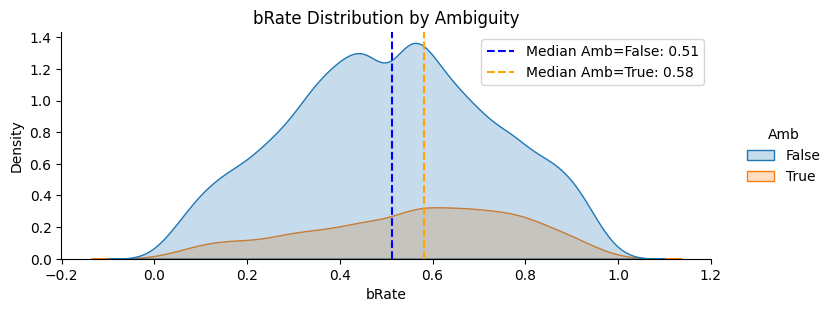

In [16]:
g = sns.displot(data=c13k, x='bRate', hue='Amb', aspect=2.5, height = 3, kind='kde', fill=True)

for amb_val, color in zip([False, True], ['blue', 'orange']):
    median = c13k[c13k['Amb'] == amb_val]['bRate'].median()
    g.ax.axvline(median, color=color, linestyle='--', linewidth=1.5, label=f'Median Amb={amb_val}: {median:.2f}')

g.ax.legend()
g.ax.set_title('bRate Distribution by Ambiguity')
plt.show()

## Machine Learning Approaches

Before proceeding, one important data structure issue must be addressed. The dataset contains multiple observations
per `Problem` — meaning many rows share the same lottery parameters. A standard random split would allow the same 
problem to appear in both train and test sets, leaking information and inflating performance metrics.

To prevent this, GroupKFold(n_splits=5) is used with `groups=Problem` throughout, ensuring each problem appears
exclusively in either train or test.

In [17]:
#Code adapted from:
#Repository: choices13k (https://github.com/jcpeterson/choices13k/blob/main/Choices13k%20Example.ipynb)
#Notebook Author: ddbourgin (David Bourgin)
all_problems = set(c13k.Problem.unique())
feedback_problems = set(c13k[c13k.Feedback == True].Problem.unique())
no_feedback_problems = set(c13k[c13k.Feedback == False].Problem.unique())

feedback_and_no_feedback_problems = feedback_problems.intersection(no_feedback_problems)
feedback_only_problems = (all_problems - feedback_and_no_feedback_problems).intersection(feedback_problems)
no_feedback_only_problems = (all_problems - feedback_and_no_feedback_problems).intersection(no_feedback_problems)

N = len(all_problems)
N_fbk = len(feedback_only_problems)
N_no_fbk = len(no_feedback_only_problems)
N_both = len(feedback_and_no_feedback_problems)

print(f"Total n. problems: {N}")
print(f"N. probs w. ONLY feedback condition: {N_fbk} ({(N_fbk / N) * 100:.2f}%)")
print(f"N. probs w. ONLY no feedback condition: {N_no_fbk} ({(N_no_fbk / N) * 100:.2f}%)")
print(f"N. probs w. BOTH feedback & no feedback conditions: {N_both} ({(N_both / N) * 100:.2f}%)")

Total n. problems: 13006
N. probs w. ONLY feedback condition: 10626 (81.70%)
N. probs w. ONLY no feedback condition: 818 (6.29%)
N. probs w. BOTH feedback & no feedback conditions: 1562 (12.01%)


The predictor variables are defined by excluding information that would not be available to the model
at prediction time (e.g. the std of bRate).

In [18]:
drop_cols = ['Problem', 'A', 'B', 'bRate', 'bRate_std', 'n', 'Block']
feature_cols = [col for col in c13k.columns if col not in drop_cols]
categorical_cols = ['LotShapeB', 'LotNumB', 'Amb', 'Corr', 'Feedback']
numerical_cols = [col for col in feature_cols if col not in categorical_cols]

X = c13k[feature_cols]
y = c13k['bRate']
groups = c13k['Problem']

## Decision Tree

Although a simple decision tree is not expected to provide the best predictive performance, it is used as a
baseline model and an initial interpretable benchmark.

A maximum tree depth of 5 was selected because it limits model complexity while still capturing important
non-linear relationships. A depth-5 decision tree can produce at most $2^5 = 32$ terminal leaf nodes and, 
therefore, predict at most 32 distinct values of `bRate`. While this limits its ability to model a continuous
target accurately, the tree can still represent non-linear relationships that a linear model cannot. Ridge is
introduced later as a linear baseline; comparing its performance against the tree — even after hyperparameter
optimization — provides a test of whether tree-based methods are genuinely better suited to the problem, and,
if so, motivates the subsequent extension to more advanced boosting models.

A `ColumnTransformer` is used to one-hot encode the categorical variables, converting them into binary indicator
columns while leaving the numerical variables unchanged.

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary'), categorical_cols),
    ],
    remainder='passthrough'
)

A decision tree is then built and evaluated by:

1. Creating a `Pipeline` that combines the preprocessing step with a `DecisionTreeRegressor`.
2. Using a `GroupKFold` object with five folds to perform grouped cross-validation, ensuring that observations
   from the same group are not split across training and validation sets.
3. Using `cross_validate` to train and evaluate the pipeline across each fold.
4. Aggregating the cross-validation results by converting negative error metrics back to positive values and
   computing the mean across folds to obtain an estimate of out-of-sample performance.

In [20]:
dt_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ))
])

cv = GroupKFold(n_splits=5)

cv_results = cross_validate(
    dt_tree,
    X, y,
    groups=groups,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
)

mae = -cv_results['test_mae']
rmse = -cv_results['test_rmse']
r2 = cv_results['test_r2']
print('CV Decision-Tree Results:')
print(f"CV MAE:  {mae.mean():.4f} ± {sem(mae):.4f}")
print(f"CV RMSE: {rmse.mean():.4f} ± {sem(rmse):.4f}")
print(f"CV R²:   {r2.mean():.4f} ± {sem(r2):.4f}")

CV Decision-Tree Results:
CV MAE:  0.0951 ± 0.0006
CV RMSE: 0.1203 ± 0.0009
CV R²:   0.7057 ± 0.0044


To inspect how the decision tree operates, the model is fitted on training data and then visualized for interpretation
purposes.

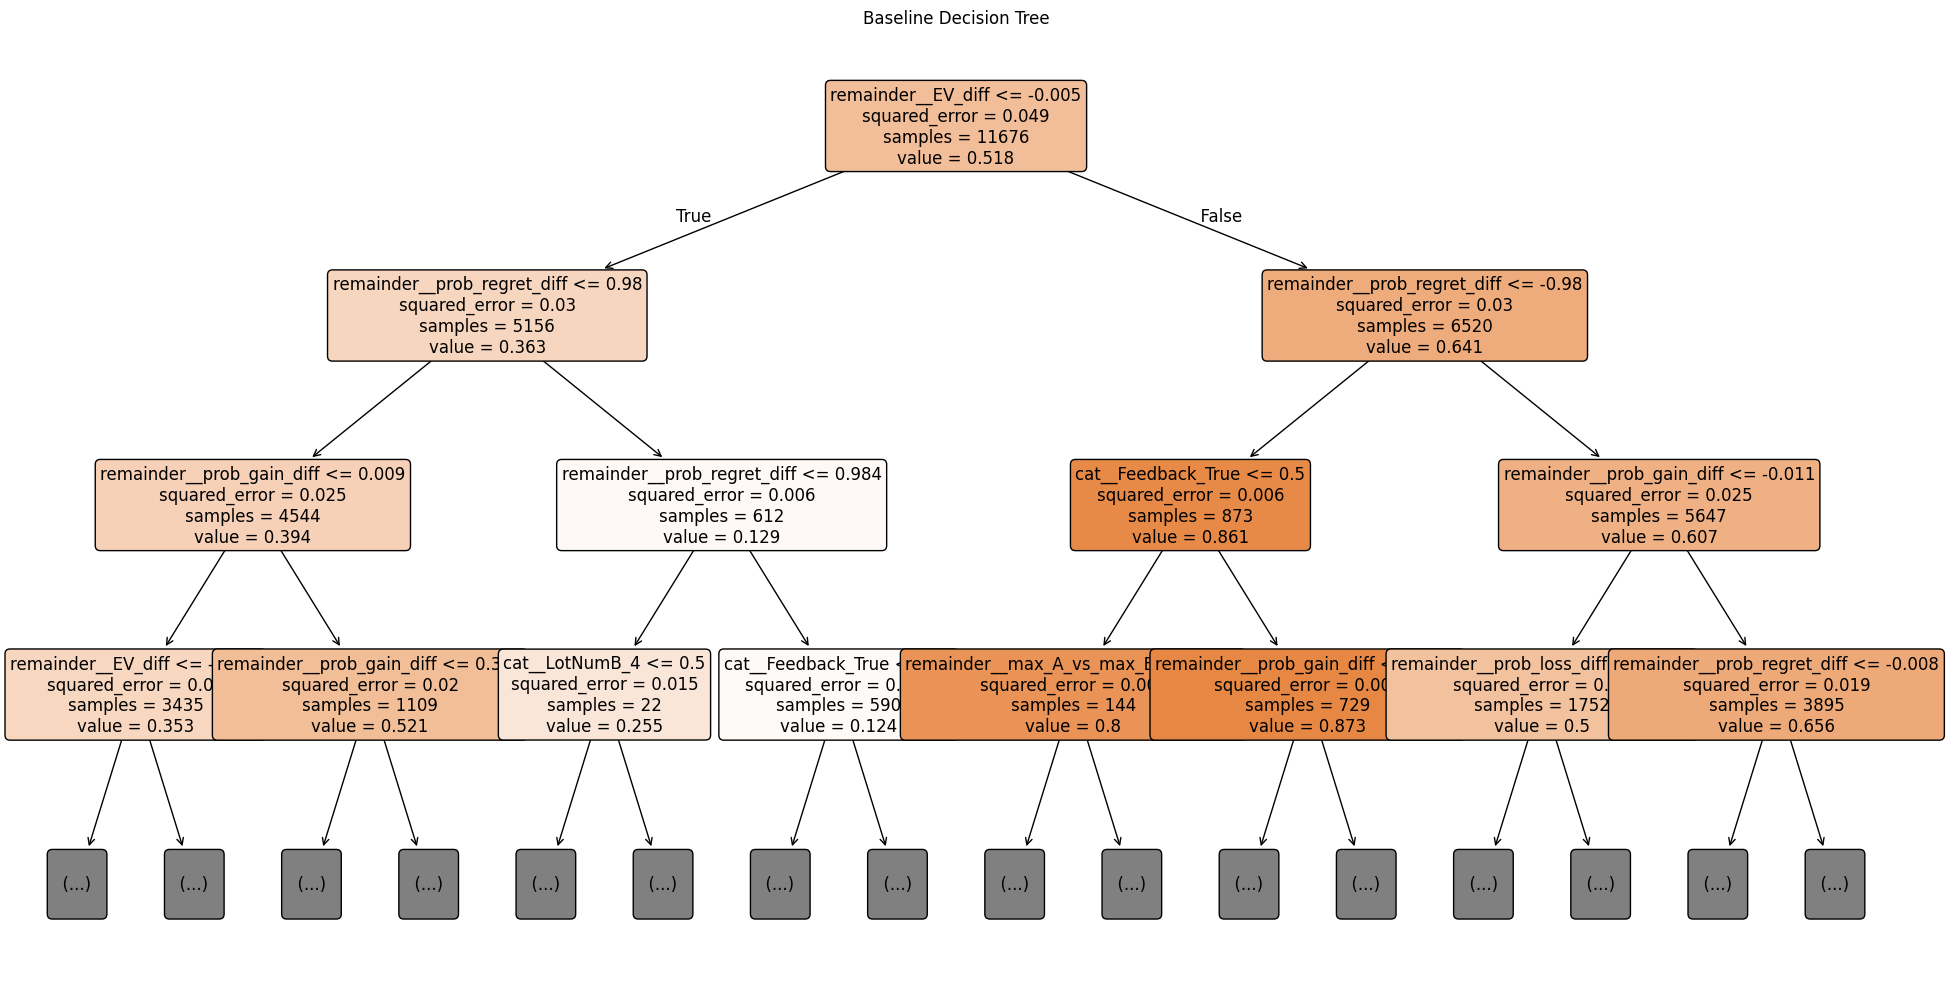

In [21]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

dt_tree.fit(X_train, y_train)

dt_feature_names = dt_tree.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    dt_tree.named_steps['regressor'],
    feature_names=dt_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("Baseline Decision Tree")
plt.tight_layout()
plt.show()

The performance of this baseline model supports the suitability of tree-based methods. Despite its simplicity, the
decision tree achieves a cross-validated $R^2$ of approximately **0.70**, while attaining a mean absolute error (MAE)
of about **9.5 percentage points**. The out-of-sample test results dispalyed below are consistent with the 
cross-validation performance, indicating stable generalisation.

Furthermore, the fact that higher-level splits are dominated by engineered features suggests that these derived variables
capture a substantial portion of the structure governing human decision-making under risk.

In [22]:
y_pred = dt_tree.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(((y_test - y_pred) ** 2).mean()))
print("Test R²:", r2_score(y_test, y_pred))

Test MAE: 0.09355608193551437
Test RMSE: 0.11792847691435566
Test R²: 0.7209338454609129


## Tuned Models

For the next models Optuna is used as the hyperparameter optimization framework due to its ease of integration
with the selected methods and its efficiency.

In [23]:
optuna.logging.set_verbosity(optuna.logging.WARNING) #silenced as not to result in giant notebook

SEED = 42
np.random.seed(SEED)

## RIDGE

Before turning to more sophisticated tree-based models, it is worth establishing, as previously stated,
whether the apparent advantage of the decision tree reflects a genuine property of the problem rather than
an artefact of how the models are compared. To this end, an optimized Ridge regression is introduced as a 
linear baseline. 

Ridge is chosen because the earlier VIF analysis revealed substantial multicollinearity among the predictors.
Ridge addresses this by introducing a regularization term that shrinks the coefficients, thereby mitigating the
adverse effects of multicollinearity.

In [24]:
ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary'), categorical_cols),
        ('num', StandardScaler(), numerical_cols),
    ]
)

The Ridge Regression is tuned and evaluated by:

1. Defining an Optuna objective function that proposes a value for the regularization strength `alpha`.
2. Using a `GroupKFold` object with five folds to perform grouped cross-validation.
3. Within each fold, fitting a `Pipeline` that combines the above preprocessing step with a Ridge regressor
   on the training data only, so that the standardization statistics required by Ridge are learned without leakage.
4. Generating predictions on the validation set for each fold and recording the evaluation metrics per fold, which
   are then averaged to obtain the cross-validated performance.
5. Returning the mean MAE as the value Optuna minimizes, and storing the corresponding RMSE and $R^2$ for each trial,
   so they can also be displayed once the best trial is identified.

In [25]:
def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-5, 1e4, log=True)
    cv = GroupKFold(n_splits=5)
    mae_scores, rmse_scores, r2_scores = [], [], []

    for train_idx, val_idx in cv.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline = Pipeline([
            ("preprocessor", ridge_preprocessor),
            ("regressor", Ridge(alpha=alpha))
        ])

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_val)

        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))

    trial.set_user_attr("rmse", float(np.mean(rmse_scores)))
    trial.set_user_attr("r2", float(np.mean(r2_scores)))
    trial.set_user_attr("mae_sem", sem(mae_scores))
    trial.set_user_attr("rmse_sem", sem(rmse_scores))
    trial.set_user_attr("r2_sem", sem(r2_scores))
    return float(np.mean(mae_scores))

The tuning is performed using the study below. Since persistence of the optimization history is not required,
the study is kept in memory rather than being stored in an SQLite database.

In [26]:
study_ridge = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_ridge.optimize(objective_ridge, n_trials=100)

print("Best Ridge trial:")
print(f"MAE:  {study_ridge.best_trial.value:.4f} ± {study_ridge.best_trial.user_attrs['mae_sem']:.4f}")
print(f"RMSE: {study_ridge.best_trial.user_attrs['rmse']:.4f} ± {study_ridge.best_trial.user_attrs['rmse_sem']:.4f}")
print(f"R²:   {study_ridge.best_trial.user_attrs['r2']:.4f} ± {study_ridge.best_trial.user_attrs['r2_sem']:.4f}")

Best Ridge trial:
MAE:  0.1010 ± 0.0006
RMSE: 0.1264 ± 0.0004
R²:   0.6752 ± 0.0030


The optimized Ridge regression achieved a cross-validated **MAE of 0.101**, an **RMSE of 0.126**, and an
**$R^2$ of 0.675** on its best trial. While these results demonstrate that the Ridge regression model
captures a substantial proportion of the variation in participants' responses, the considerably simpler,
untuned depth-5 decision tree achieved better performance across all three metrics (**MAE = 0.0951**,
**RMSE = 0.1203**, **$R^2$ = 0.706**). These results support the previous claims that tree-based methods
are better suited to the problem than linear models. Consequently, the next step is to investigate a more
powerful tree-based approach by employing a gradient boosting model with hyperparameter optimization.

# LightGBM

After experimenting with several gradient boosting methods, including XGBoost, LightGBM gave the best results.
To keep the notebook concise and within a reasonable runtime, only LightGBM is presented here;

The LightGBM approach is similar to the Ridge approach above in that the structure of the objective function,
the use of `GroupKFold`, the per-fold recording of evaluation metrics, and the returned metric are similar.
The main differences are the following:

- LightGBM searches a much larger hyperparameter space than Ridge, which tunes only the single regularization
  strength
- The categorical features are handled natively rather than one-hot encoded, since LightGBM supports this
  directly.
- Within each outer `GroupKFold` training fold, a `GroupShuffleSplit` is used to create a separate early-stopping
  validation set. This set is used exclusively to determine the optimal number of boosting iterations, while the
  outer validation fold remains completely unseen until final evaluation. This separation ensures that the
  cross-validation performance estimates remain unbiased.
- The best iteration selected by early stopping is stored for each outer fold, so that the median of these values
  can be used as the number of boosting rounds when fitting the final model.

In [27]:
def objective(trial):
    param = {
        "objective": "regression",
        "metric": "l1",
        "verbosity": -1,
        "num_threads": 1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1),
        "n_estimators": 1000,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }


    cv = GroupKFold(n_splits=5)
    mae_scores, rmse_scores, r2_scores = [], [], []
    best_iters = [] 
    for train_idx, val_idx in cv.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        g_train = groups.iloc[train_idx]

        inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        fit_idx, es_idx = next(inner.split(X_train, y_train, groups=g_train))

        X_fit, X_es = X_train.iloc[fit_idx], X_train.iloc[es_idx]
        y_fit, y_es = y_train.iloc[fit_idx], y_train.iloc[es_idx]

        dtrain = lgb.Dataset(X_fit, label=y_fit,
                     categorical_feature=categorical_cols)
        dvalid = lgb.Dataset(X_es, label=y_es, reference=dtrain)

        gbm = lgb.train(param, dtrain, valid_sets=[dvalid],
            valid_names="valid",
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1)
        ],
        )
        best_iters.append(gbm.best_iteration)
        preds = gbm.predict(X_val)
        
        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))
        
    trial.set_user_attr("rmse", float(np.mean(rmse_scores)))
    trial.set_user_attr("r2", float(np.mean(r2_scores)))
    trial.set_user_attr("best_iters", best_iters)
    trial.set_user_attr("mae_sem", float(sem(mae_scores)))
    trial.set_user_attr("rmse_sem", float(sem(rmse_scores)))
    trial.set_user_attr("r2_sem", float(sem(r2_scores)))

    return np.mean(mae_scores)

Once again, since persistence of the optimization history is not required, the study is kept in memory
rather than stored in an SQLite database. Additionally, to reduce the notebook's execution time, the
search is capped at the number of trials at which the best trial was found.

In [28]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=6)

print("Best LGBM trial:")
print(f"MAE:  {study.best_trial.value:.4f} ± {study.best_trial.user_attrs['mae_sem']:.4f}")
print(f"RMSE: {study.best_trial.user_attrs['rmse']:.4f} ± {study.best_trial.user_attrs['rmse_sem']:.4f}")
print(f"R²:   {study.best_trial.user_attrs['r2']:.4f} ± {study.best_trial.user_attrs['r2_sem']:.4f}")

Best LGBM trial:
MAE:  0.0744 ± 0.0004
RMSE: 0.0937 ± 0.0007
R²:   0.8216 ± 0.0035


The best LightGBM trial's corresponding hyperparameters are used below to construct the final LightGBM model,
which will be evaluated using the 5-fold grouped cross-validation to estimate its predictive performance on
unseen data.

In [29]:
print('Number of finished trials: ', len(study.trials))
print('Best trial:')
best_trial = study.best_trial

print('Value: ', best_trial.value)
print('Params: ')
for key, value in best_trial.params.items():
    print(f'\t{key}: {value}')

Number of finished trials:  6
Best trial:
Value:  0.07443569482745081
Params: 
	num_leaves: 69
	learning_rate: 0.021199791750292695
	colsample_bytree: 0.43903095579116774
	subsample: 0.9693313223519999
	subsample_freq: 10
	min_child_samples: 82


In [30]:
cv = GroupKFold(n_splits=5)

n_est = int(np.median(study.best_trial.user_attrs["best_iters"]))
gbm = lgb.LGBMRegressor(**study.best_params, n_estimators=n_est, n_jobs=1)

scores = cross_validate(
    gbm,
    X, y,
    groups=groups,
    cv=cv,
    scoring={
        'mae':  'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    },
    n_jobs=-1,
    return_estimator=True,
)

print("Final LightGBM (5-fold Group CV)")
print(f"MAE:  {np.mean(-scores['test_mae']):.4f} ± {sem(-scores['test_mae']):.4f}")
print(f"RMSE: {np.mean(-scores['test_rmse']):.4f} ± {sem(-scores['test_rmse']):.4f}")
print(f"R²:   {np.mean(scores['test_r2']):.4f} ± {sem(scores['test_r2']):.4f}")

Final LightGBM (5-fold Group CV)
MAE:  0.0740 ± 0.0004
RMSE: 0.0930 ± 0.0007
R²:   0.8239 ± 0.0033


The final LightGBM model achieved a **mean MAE of 0.0734 ± 0.0004**, a **mean RMSE of 0.093 ± 0.0006**, and a 
**mean (R^2) of 0.824 ± 0.003** under 5-fold grouped cross-validation. These results indicate that the model
generalizes well to unseen decision problems while exhibiting low variability across the cross-validation folds.
Furthermore, the LightGBM model outperformed both the Decision Tree and Ridge Regression models across all evaluation
metrics, making it the best-performing model for this prediction task. As such, the corresponding cross-validated
MAE is reported in the final cell of the notebook, and the model is refitted below on the full dataset for feature
importance and SHAP analyses.

# FEATURE IMPORTANCE ANALYSIS

## LightGBM Plot Importance

Having estimated the model's generalization performance through cross-validation, the final LightGBM model
is refitted on the full dataset to analyse feature importance. This enables the use of LightGBM's built-in
`lgb.plot_importance` function, which provides an efficient, model-specific estimate of feature importance
and serves as a fast baseline against which the subsequent, more rigorous importance measures can be compared.

In [31]:
gbm.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,69
,max_depth,-1
,learning_rate,0.021199791750292695
,n_estimators,447
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,82


As stated in [GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/lightgbm-feature-importance-and-visualization/),
LightGBM provides two main types of feature importance scores: `Split` and `Gain`.

- Split Feature Importance: This type measures the number of times a feature is used to split the
  data across all trees in the model. It is useful for identifying which features are most often
  involved in the decision-making process.

- Gain Feature Importance: Gain importance, on the other hand, quantifies the improvement in the
  model's accuracy achieved by using a particular feature for splitting. It provides a more informative
  view of feature importance, as it considers the quality of the splits as well.



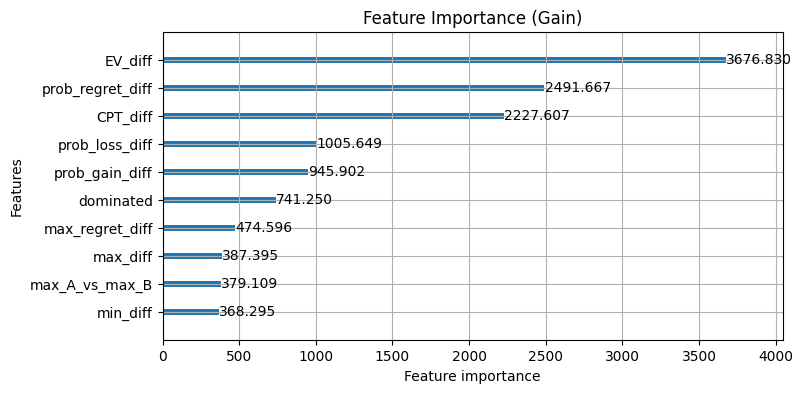

In [32]:
_ = lgb.plot_importance(gbm, importance_type='gain',
                        max_num_features=10, figsize=(8, 4),
                       title='Feature Importance (Gain)')

The figure shows that `EV_diff` is by far the most influential feature, followed by
`CPT_diff`, `prob_regret_diff`, and `prob_gain_diff`. Notably, all ten of the most
important features according to the gain criterion are engineered rather than
directly extracted from the original dataset.

Although evaluating behavioural theories is beyond the scope of this assignment,
the prominence of `EV_diff` and `CPT_diff`, derived from Expected Value and
Cumulative Prospect Theory respectively, suggests that these established
frameworks do in fact provide informative representations for predicting participants'
decisions.

From a modelling perspective, `EV_diff` and `CPT_diff` are expected to capture
overlapping information, as both measure the relative attractiveness of the two
gambles. However, their joint importance suggests that participants' choices are
influenced by both normative evaluation and behavioural effects, while the
remaining important features capture additional influences such as anticipated
regret and the probability of obtaining gains.

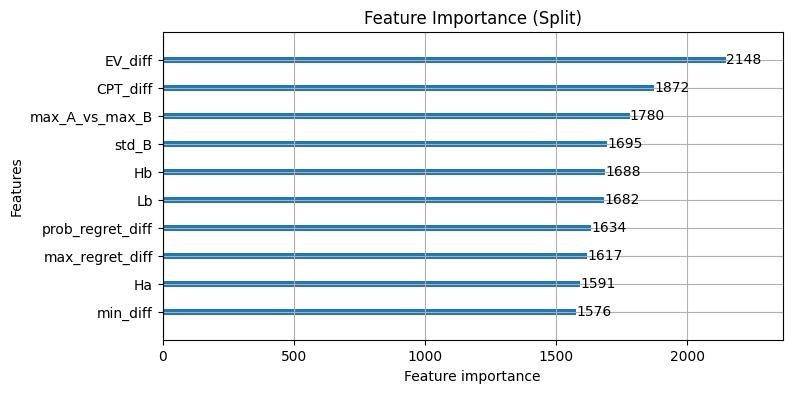

In [33]:
_ = lgb.plot_importance(gbm, importance_type='split',
                        max_num_features=10, figsize=(8, 4),
                       title='Feature Importance (Split)')

As split importance reflects how often a feature is selected for a split rather than how much each 
split improves the model, features such as `Hb` appear among the most frequently used predictors 
despite their relatively low gain importance. Among the top ten features by split importance,
three original variables (`Hb`, `Lb`, and `La`) appear, compared with none in the gain-based ranking.
The original variables nonetheless remain a minority of the top ten, which suggests that, although 
they are frequently used to refine the decision trees, the engineered features are the principal 
contributors to reducing prediction error.

This distinction is reinforced by `EV_diff`, `CPT_diff`, `max_A_vs_max_B`, `max_regret_diff` and
`min_diff` which rank in the top 10 under both criteria, meaning that they are not only selected
frequently but also produce informative splits that substantially reduce error. Taken together, the
two rankings indicate that the raw lottery parameters are used mainly for frequent, fine-grained 
refinement of the trees, while the engineered features drive the bulk of the model's predictive
performance.

##  Permutation Feature Importance

For a more rigorous assessment, permutation feature importance is computed. This method evaluates
the fitted model on each validation fold, then each feature column is shuffled independently
while all other features remain unchanged. The resulting increase in MAE is recorded, and the
mean increase across several repetitions is taken as the feature's importance.

To obtain more robust estimates, permutation importance is computed separately for each 
cross-validation fold and the resulting importance scores are averaged across folds.

It should be noted, that when two features are strongly correlated, permuting one still leaves the
model access to the information through the other, which means that both features may appear less 
important than they actually are.

In [34]:
perm_importances = []
fold=1

for estimator, (_, val_idx) in zip(scores["estimator"], 
                                cv.split(X, y, groups=groups)):

    print(f'Evaluating permutation importance for fold {fold}...')
    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]
    result = permutation_importance(
        estimator, X_val, y_val,
        n_repeats=5,
        random_state=42,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    perm_importances.append(result.importances_mean)
    fold += 1 

Evaluating permutation importance for fold 1...
Evaluating permutation importance for fold 2...
Evaluating permutation importance for fold 3...
Evaluating permutation importance for fold 4...
Evaluating permutation importance for fold 5...


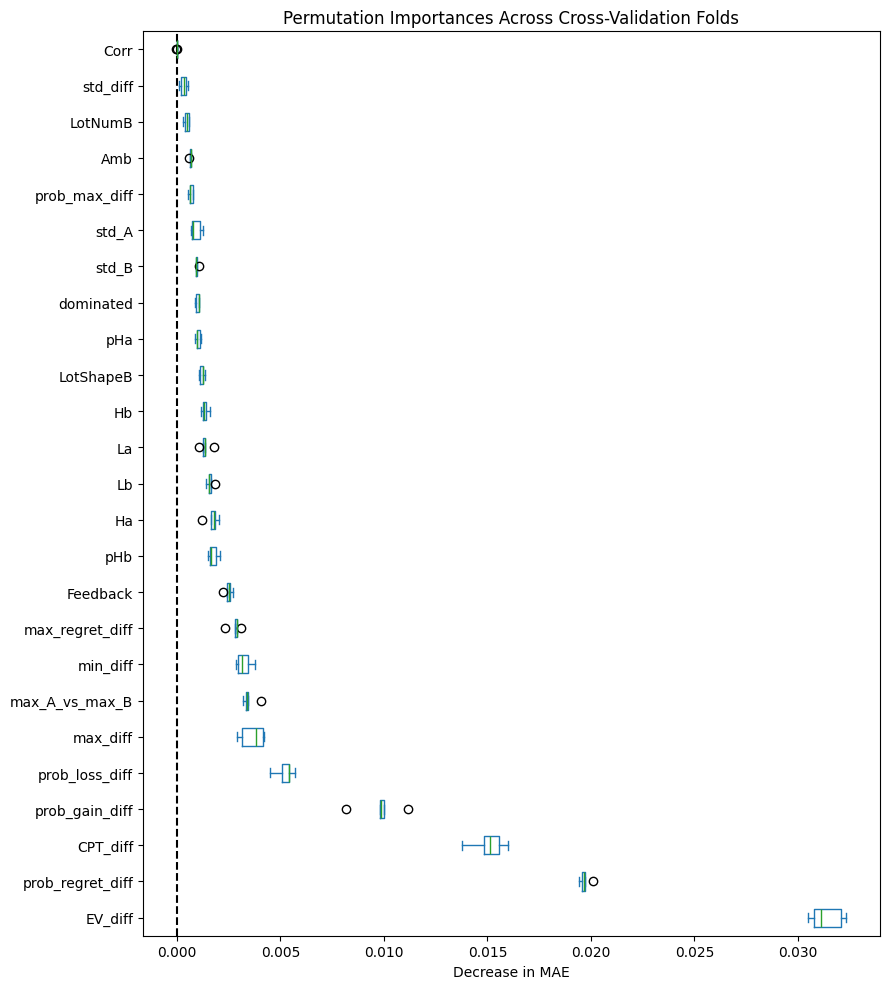

In [35]:
perm_importances = np.array(perm_importances)

perm_df = (
 pd.DataFrame({
 "Feature": X.columns,
 "Importance": perm_importances.mean(axis=0),
 "Std": perm_importances.std(axis=0)
 })
 .sort_values("Importance", ascending=False)
)

sorted_features = perm_df["Feature"].tolist()

feat_list = list(X.columns)
sorted_idx = [feat_list.index(f) for f in sorted_features]

importances_df = pd.DataFrame(
    perm_importances[:, sorted_idx],
    columns=sorted_features
)

ax = importances_df.plot.box(
    vert=False,
    figsize=(9, 10)
)

ax.set_title("Permutation Importances Across Cross-Validation Folds")
ax.set_xlabel("Decrease in MAE")
ax.axvline(x=0, color="black", linestyle="--")

plt.tight_layout()
plt.show()

The most notable feature of this plot is that only a small number of features have boxes lying clearly to
the right of the dashed zero line (the x-axis spans from 0.00 to 0.03). These are the features whose
permutation reliably increases the error across folds and can therefore be regarded as genuinely important,
while the majority of the remaining features cluster around zero, indicating that permuting them has little
or no effect on performance.

This pattern is itself informative: the original lottery parameters produce almost no decrease in performance
when permuted, despite appearing frequently in the split-based ranking. This is consistent with the 
multicollinearity identified earlier, which means that the information contained in the raw variables is largely
also encoded in the engineered features, due to how they are computed, so that shuffling any single raw variable
leaves the model able to recover the same information from correlated predictors. The permutation results 
therefore reinforce the conclusion that the engineered features account for the majority of the model's unique
predictive signal.

Taken together, the consistent presence of `EV_diff`, `CPT_diff`, `prob_regret_diff` and `min_diff` across the 
three different ways of measuring importance invites the following interpretation on what makes people more or
less likely to pick gamble B:

> A big part of human decision-making is a mix of calculated thinking (EV_diff), which is then skewed by people's biases
> — the slightly distorted way people tend to weigh risks and rewards (CPT_diff). On top of that, there's a tendency to
> avoid the choice they'd most regret later (prob_regret_diff) and to lean toward the option that's safer if things go
> badly (min_diff). The more an option scores well on these counts, the larger the share of people who end up choosing
> it — which is exactly what bRate captures.

However, while these are reasonable interpretations, `lgb.plot_importance` and `Permutation Feature Importance` only quantify
how much each feature matters on average; they show nothing about the direction of those effects.

## Shapley Values and SHAP

SHAP (SHapley Additive exPlanations) fills this gap. Building on the Shapley value from cooperative game theory,
it splits each individual prediction among the features, showing whether a feature pushed the predicted `bRate`
up (towards Gamble B) or down (towards Gamble A), and by how much.

Although SHAP values can be computed on any set of instances, including the full dataset, computing on held-out
test data is considered best practice because:
  
  * it ensures explanations describe model behaviour on *unseen* instances
  * there is no risk of artefacts from overfitting on the specific training points

Therefore, the final LightGBM model is refitted on the training split, and SHAP values are computed for X_test.

In [36]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

In [37]:
gbm_shap = lgb.LGBMRegressor(
    **study.best_params,
    n_estimators=n_est,
    n_jobs=1
)

gbm_shap.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

,boosting_type,'gbdt'
,num_leaves,69
,max_depth,-1
,learning_rate,0.021199791750292695
,n_estimators,447
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,82


In [38]:
explainer = shap.TreeExplainer(gbm_shap)

# Wrap X_test in a DataFrame so SHAP carries the feature names into all plots
X_test_df = pd.DataFrame(X_test, columns=X.columns)
shap_values = explainer(X_test_df)

baseline = explainer.expected_value

print(f"SHAP values shape : {shap_values.values.shape}")
print(f"Baseline (E[f(X)]): {baseline:.4f}")
print(f"First test instance:")
# The following two should be equal (up to numerical precision)
print(f"  Predicted value  : {gbm_shap.predict(X_test_df.iloc[[0]])[0]:.4f}")
print(f"  Baseline + SHAP  : {baseline + shap_values.values[0].sum():.4f}")

SHAP values shape : (2892, 25)
Baseline (E[f(X)]): 0.5185
First test instance:
  Predicted value  : 0.4698
  Baseline + SHAP  : 0.4698


One way to visualize SHAP values is though a `beeswarm plot`. A beeswarm plot is used to provide a global 
summary of the SHAP values. In this plot, each dot represents a single test instance, while its horizontal
position corresponds to the SHAP value, indicating the feature's contribution to the prediction. The colour
of each dot encodes the original feature value (red = high, blue = low), and the features are ordered by 
their mean absolute SHAP values, with the most globally important features appearing at the top. A pattern
where high feature values correspond to large positive SHAP values indicates a positive relationship between
the feature and the predicted bRate, whereas the opposite pattern indicates a negative relationship.

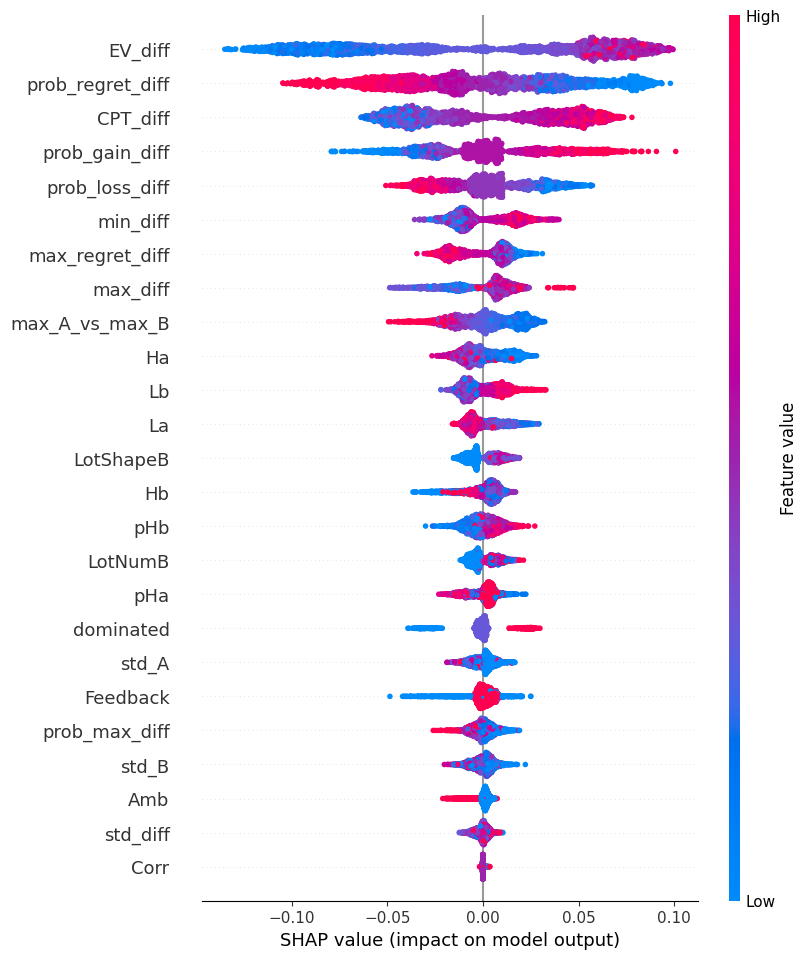

In [39]:
shap.plots.beeswarm(shap_values, max_display=len(X.columns))

Once again the most influential features are the engineered behavioural features `EV_diff`, `CPT_diff` and 
`prob_regret_diff` with others seen in the previous plot close by (e.g. `min_diff` and `prob_gain_diff`.
As expected, the colour gradients reveal that higher values of `EV_diff`, `CPT_diff`, and `prob_gain_diff`
generally increase the predicted `bRate`, whereas higher values of `prob_regret_diff` reduce it. Interestingly, 
for `EV_diff`, observations with intermediate feature values are associated with positive SHAP values. This
suggests that moderate differences in expected value are often sufficient to increase the model's predicted 
proportion of participants choosing Gamble B.

The original variables also mostly display monotonic relationships but with a much denser distribution of SHAP
values around zero, leading to the conclusion that they act primarily as secondary refinements rather than the
main drivers of the model's predictions. This is consistent with the gain and permutation-based importance
analyses presented earlier.

Finally, to demonstrate how the model constructs an individual prediction, a `SHAP waterfall plot` is presented
for the test instance with the highest predicted `bRate`. A waterfall plot visualizes how the contributions of
individual features combine to produce a single prediction. Starting from the baseline prediction, red bars 
increase and blue bars decrease the predicted value.

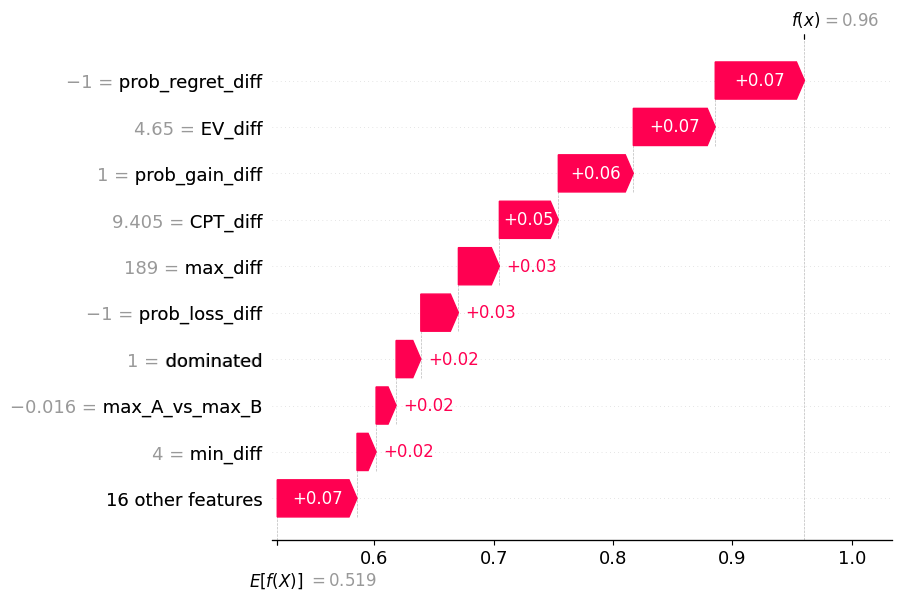

In [40]:
max_pred_idx = gbm_shap.predict(X_test_df).argmax()

shap.plots.waterfall(shap_values[max_pred_idx])

Starting from the baseline prediction of approximately **0.52**, the model accumulates a series
of positive feature contributions until reaching a final predicted `bRate` of approximately 
**0.96**. In this instance, every displayed feature increases the prediction, indicating that
the characteristics of the lottery collectively make participants highly likely to choose Gamble
B. The largest contributions come from `prob_regret_diff`, `EV_diff`, `prob_gain_diff`, and 
`CPT_diff`, which together account for approximately **25 percentage points** of the total 
**44-percentage-point** increase from the baseline prediction. Smaller positive contributions 
arise from `max_diff`, `prob_loss_diff`, `dominated`, `max_A_vs_max_B`, and `min_diff`, while
the remaining sixteen features contribute a combined increase of approximately **7 percentage points**,
highlighting their comparatively limited influence on this prediction.

Interestingly, although `max_A_vs_max_B` has a value of **−0.016**, indicating that the best possible 
outcome in Gamble A is still a loss relative to the best possible outcome in Gamble B, it contributes
only around **2 percentage points** to the prediction. This suggests that, while the model recognises
the superiority of Gamble B's maximum outcome, this information provides only incremental predictive
value once the stronger behavioural features, such as `EV_diff`, `CPT_diff`, `prob_regret_diff`, and
`prob_gain_diff`, have already been taken into account.

All in all, the results from all three feature importance methods indicate that the model relies primarily
on the engineered behavioural features, especially `EV_diff`, `CPT_diff`, and `regret-based measures`, while
the raw lottery variables play a secondary role.

## Conclusion

This assignment demonstrates that human choices under uncertainty can be predicted effectively through
theory-driven feature engineering and appropriate machine learning methods. The results highlight the
value of building upon established behavioural theories, as features derived from concepts such as
`Cumulative Prospect Theory` proved substantially more informative than the original lottery variables.
They also suggest that human decision-making reflects a combination of rational evaluation and behavioural
biases rather than purely rational choice. Finally, the comparison between models illustrates the importance
of selecting methods that are well suited to the problem, as even a simple Decision Tree outperformed a carefully
tuned Ridge regression, while LightGBM achieved the best overall MAE as shown in the cell below:

In [41]:
print('BEST MAE ', np.mean(-scores['test_mae']),  sem(-scores['test_mae']))

BEST MAE  0.07397950542467371 0.00037766600056328604
